# Baltic macroeconomic normalized dashboard snapshot

This notebook renders only the normalized z-score summary visuals for the Baltic countries.

- Countries covered: Lithuania, Latvia, Estonia
- Visuals: `zscore_heatmap` and `zscore_timelines`
- Output root: `bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics`


In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
search_roots = [current_dir, *current_dir.parents]
module_path = next(
    (
        p
        for p in search_roots
        if (p / "macro_indicator_core.py").exists() and (p / "macro_indicator_pipeline.py").exists()
    ),
    None,
)
if module_path is None:
    module_path = next((p for p in search_roots if (p / "macro_indicator_pipeline.py").exists()), None)
if module_path is None:
    raise FileNotFoundError("macro_indicator_pipeline.py not found in current or parent directories.")

if str(module_path.resolve()) not in sys.path:
    sys.path.insert(0, str(module_path.resolve()))

from macro_indicator_pipeline import (
    build_country_zscore_notebook_context,
    display_country_zscore_visuals,
    get_pipeline_root,
    run_country_batch,
)


In [2]:
root = get_pipeline_root()
project_subdir = Path("bs2026_student_projects") / "Arturas_Sotnicenko"
output_root = root / project_subdir / "outputs_baltics"

country_codes = ("LT", "LV", "EE")
chart_profile = "harmonized_overlay"
normalized_region_label = "Baltics"
normalization_config = None
force_zscore_refresh = False

# Example dynamic config:
# normalization_config = {
#     "mode": "rolling_trailing",
#     "rolling_window_years": 10,
#     "exclude_current_from_window": True,
#     "min_obs_for_zscore": 5,
# }

print(f"Countries: {country_codes}")
print(f"Chart profile: {chart_profile}")
print(f"Normalized region label: {normalized_region_label}")
print(f"Dynamic normalization enabled: {normalization_config is not None}")
print(f"Output root: {output_root.resolve()}")


Countries: ('LT', 'LV', 'EE')
Chart profile: harmonized_overlay
Normalized region label: Baltics
Dynamic normalization enabled: False
Output root: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics


In [3]:
batch = run_country_batch(
    country_codes=country_codes,
    outdir_root=str(output_root),
    include_analysis=True,
    reuse_existing=True,
    chart_profile=chart_profile,
)

country_results = batch["country_results"]
country_output_dirs = batch["country_output_dirs"]


In [4]:
def _render_country_normalized_section(
    country_code: str,
    *,
    normalization_config=normalization_config,
    region_label=normalized_region_label,
    force_refresh=force_zscore_refresh,
):
    country_context = build_country_zscore_notebook_context(
        country_code=country_code,
        country_results=country_results[country_code],
        country_output_dir=country_output_dirs[country_code],
        normalization_config=normalization_config,
        region_label=region_label,
        force_refresh=force_refresh,
        root=root,
    )
    display_country_zscore_visuals(country_context)
    return country_context


## Lithuania


## Static z-score visuals

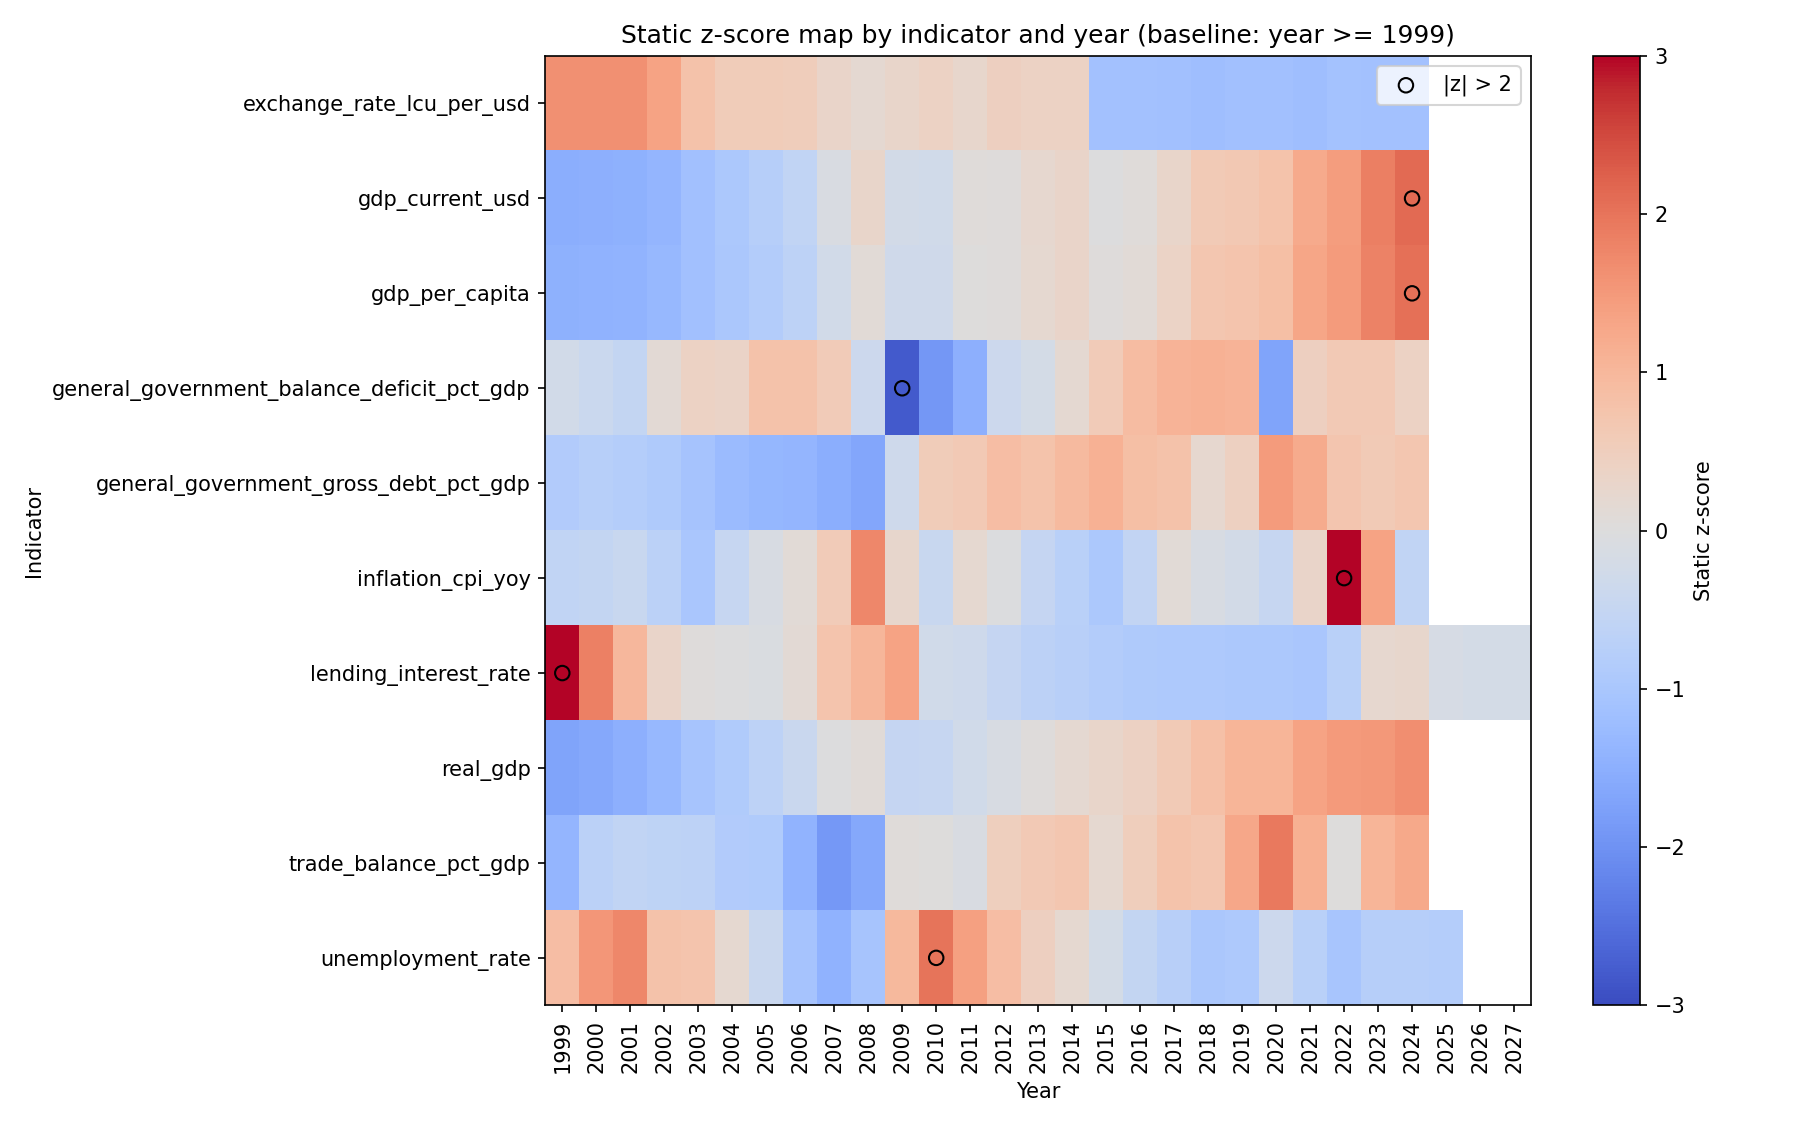

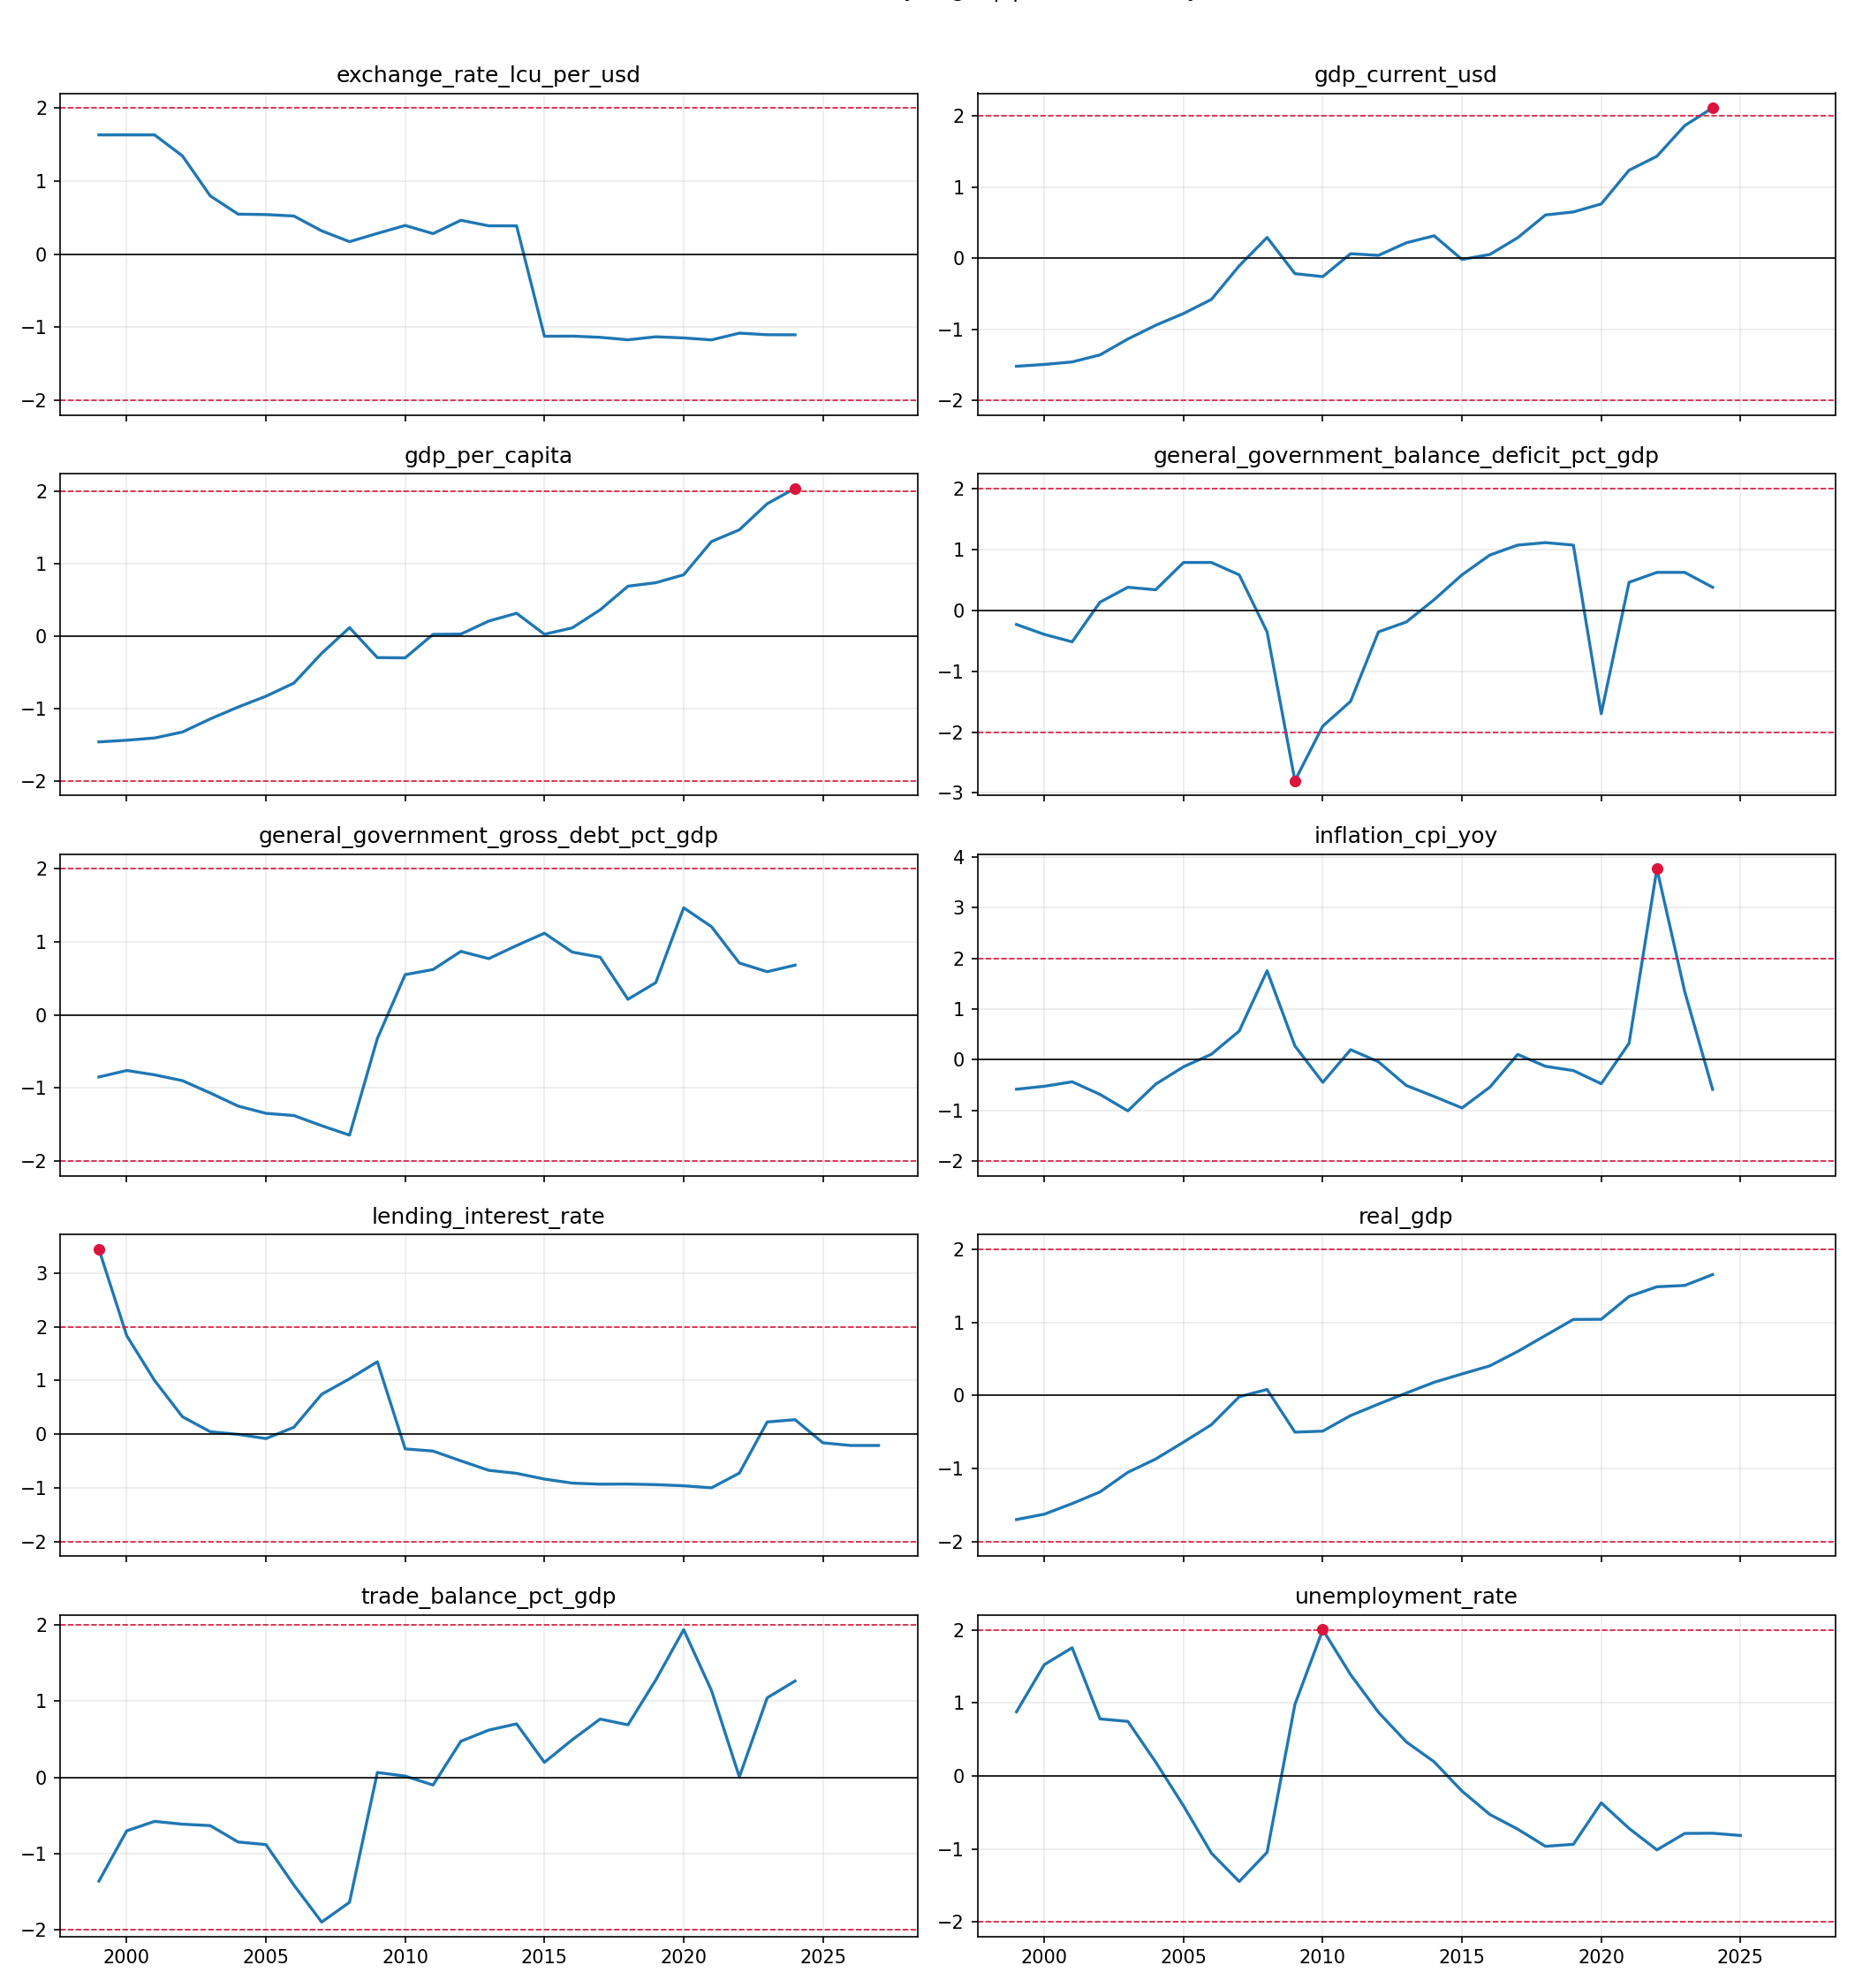

In [5]:
_lt_context = _render_country_normalized_section("LT")


## Latvia


## Static z-score visuals

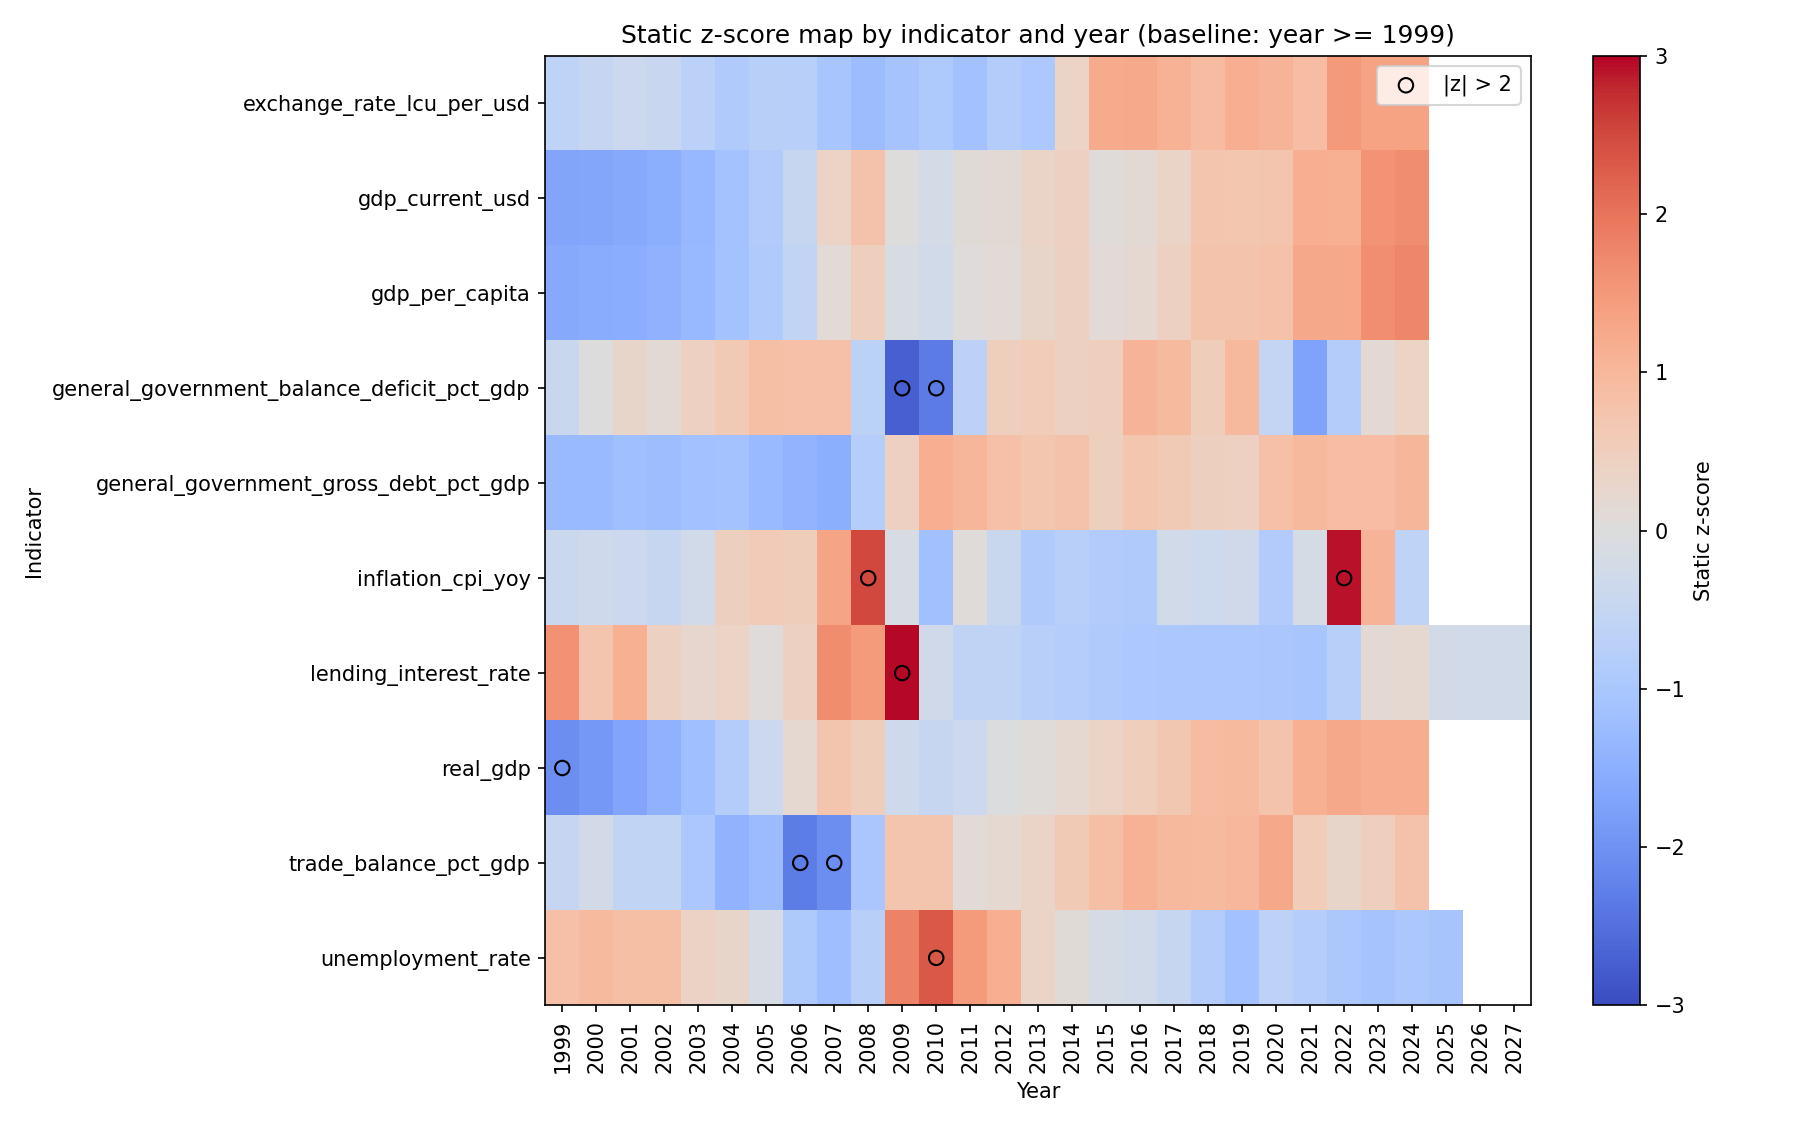

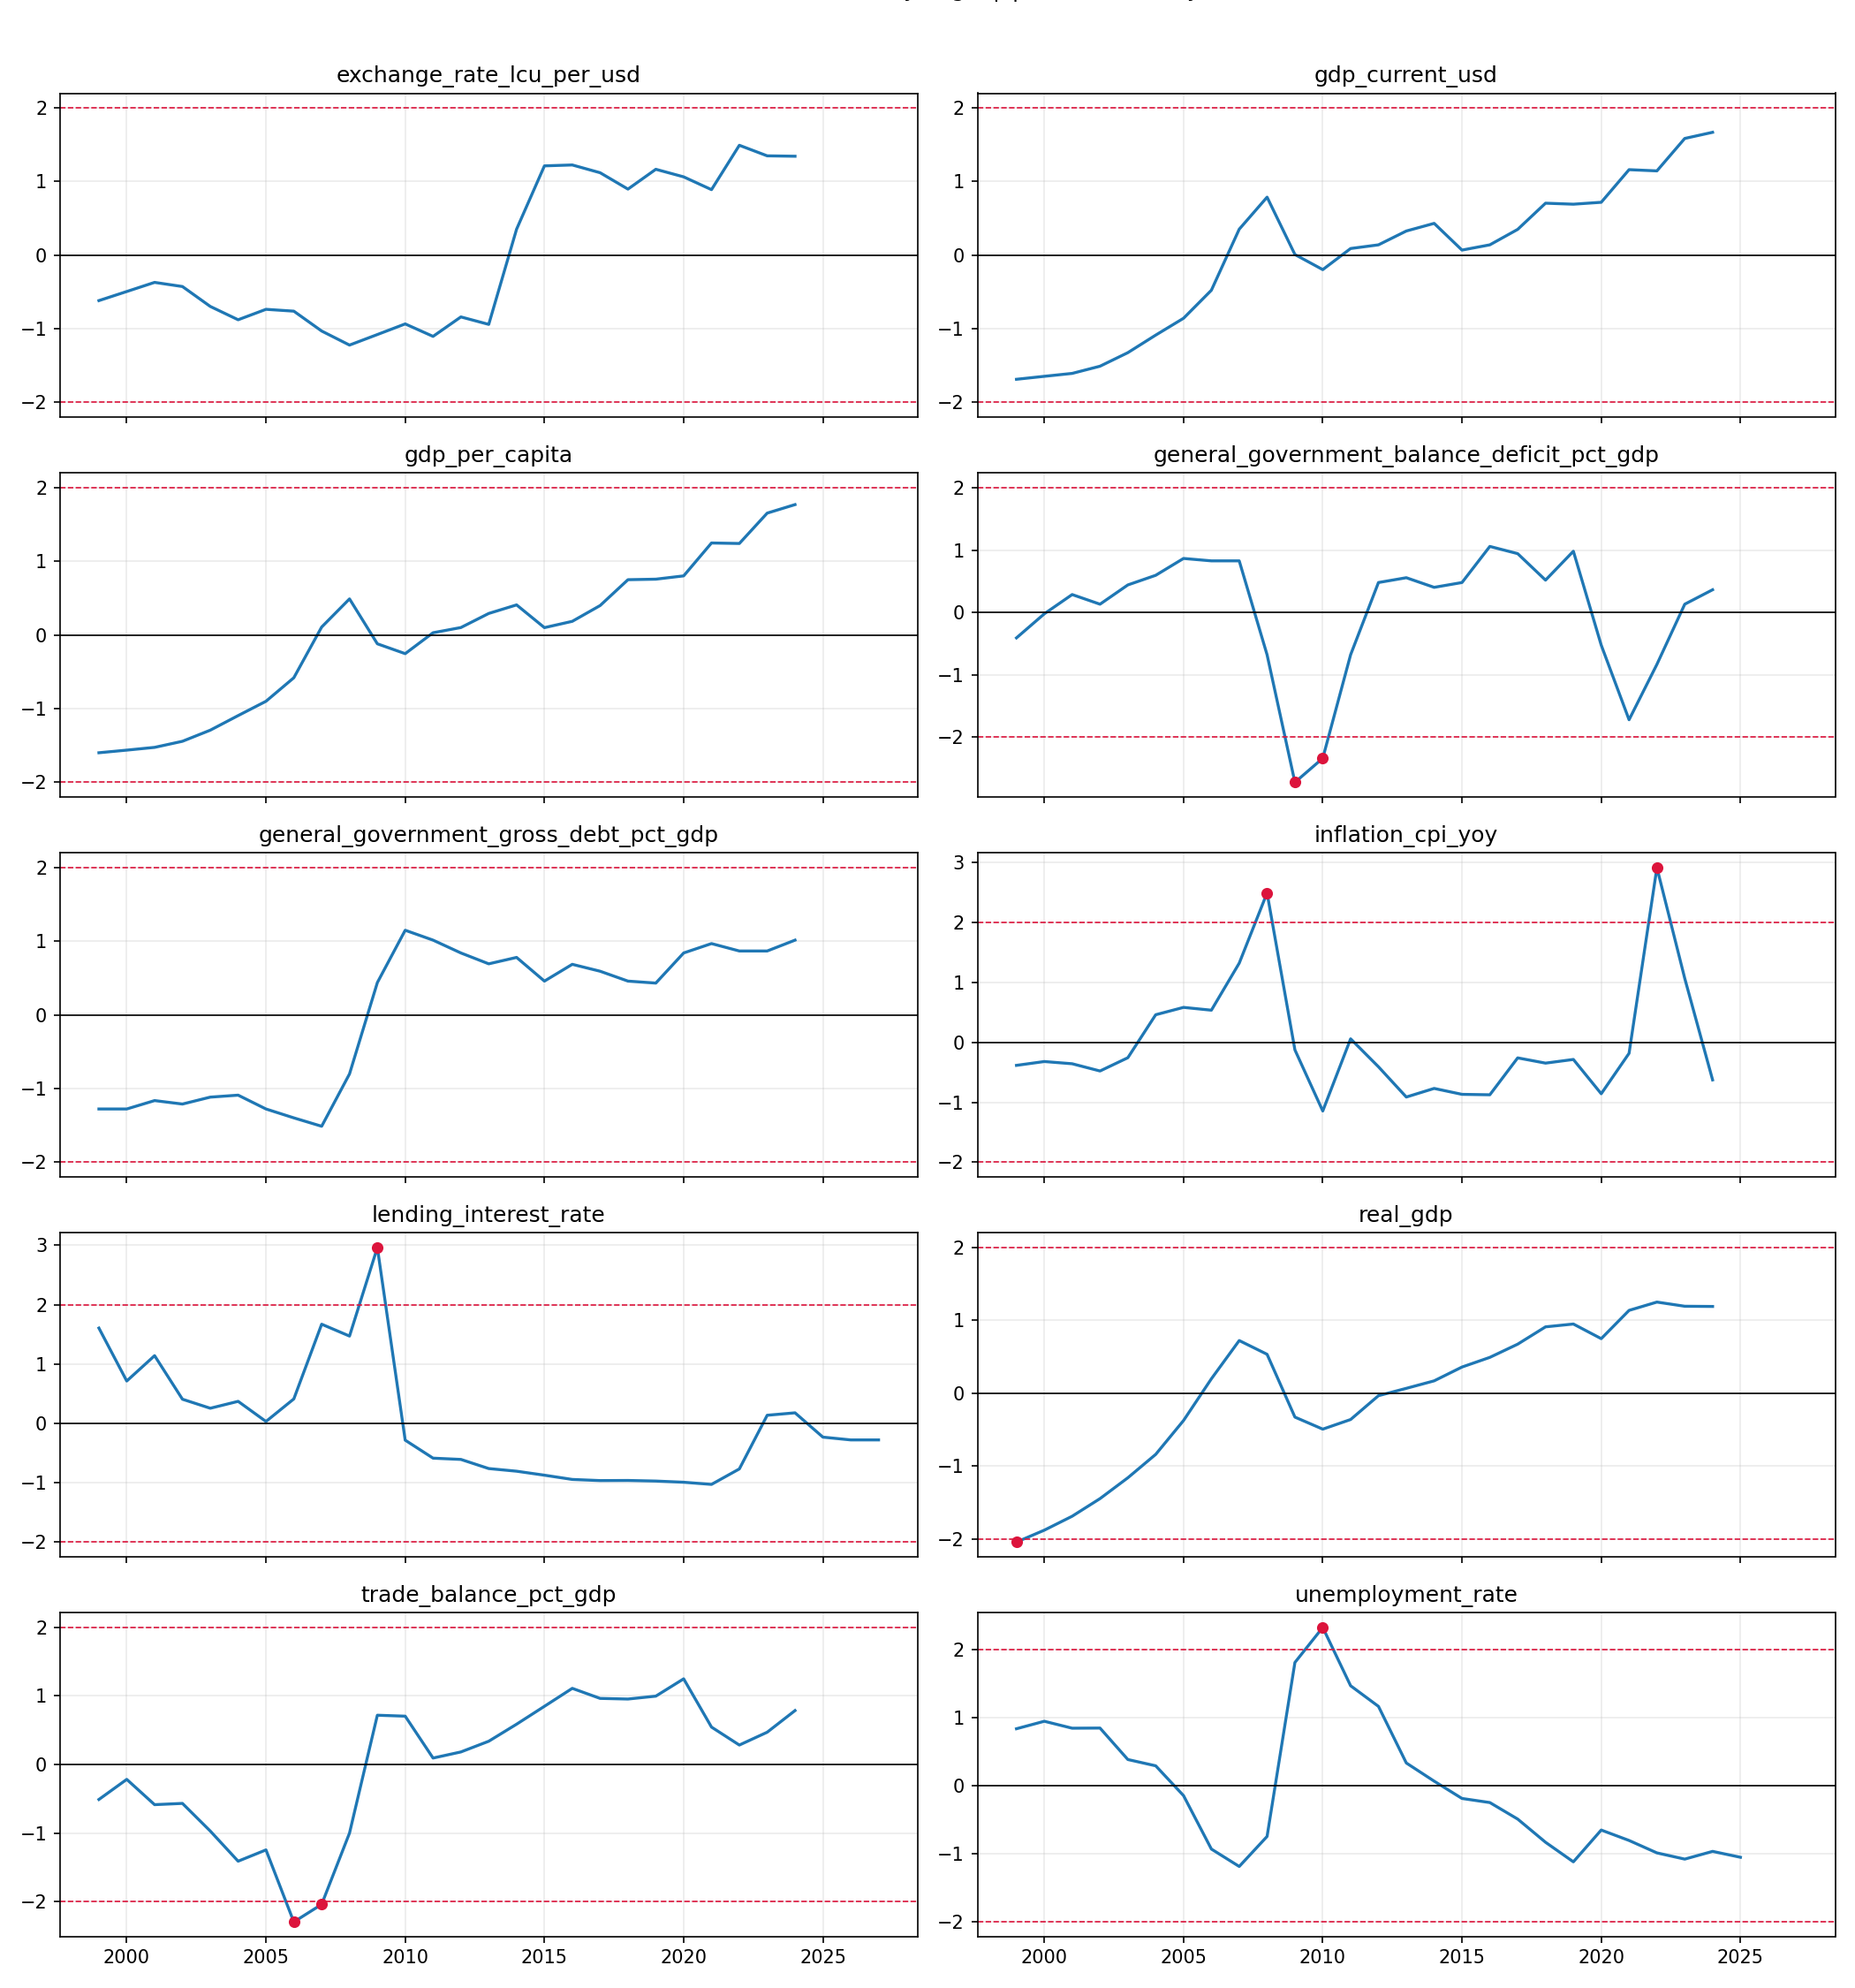

In [6]:
_lv_context = _render_country_normalized_section("LV")


## Estonia


## Static z-score visuals

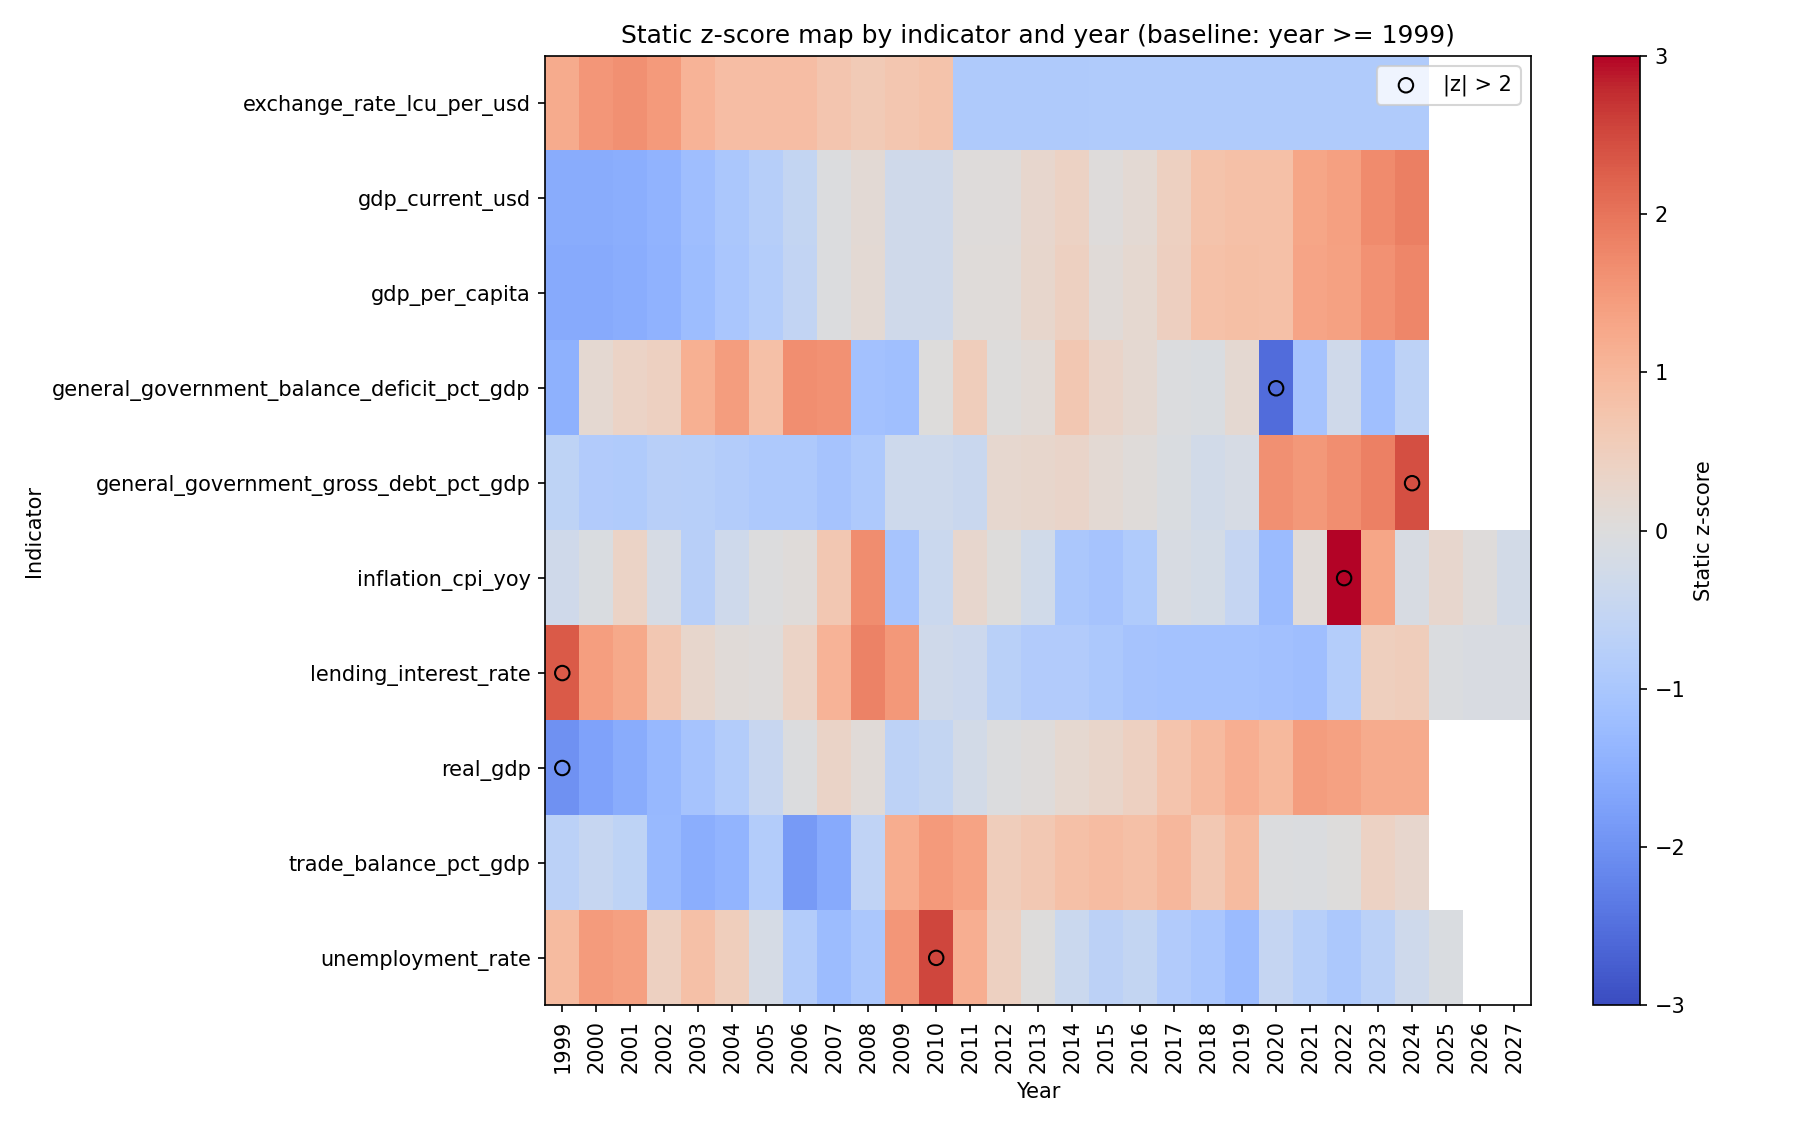

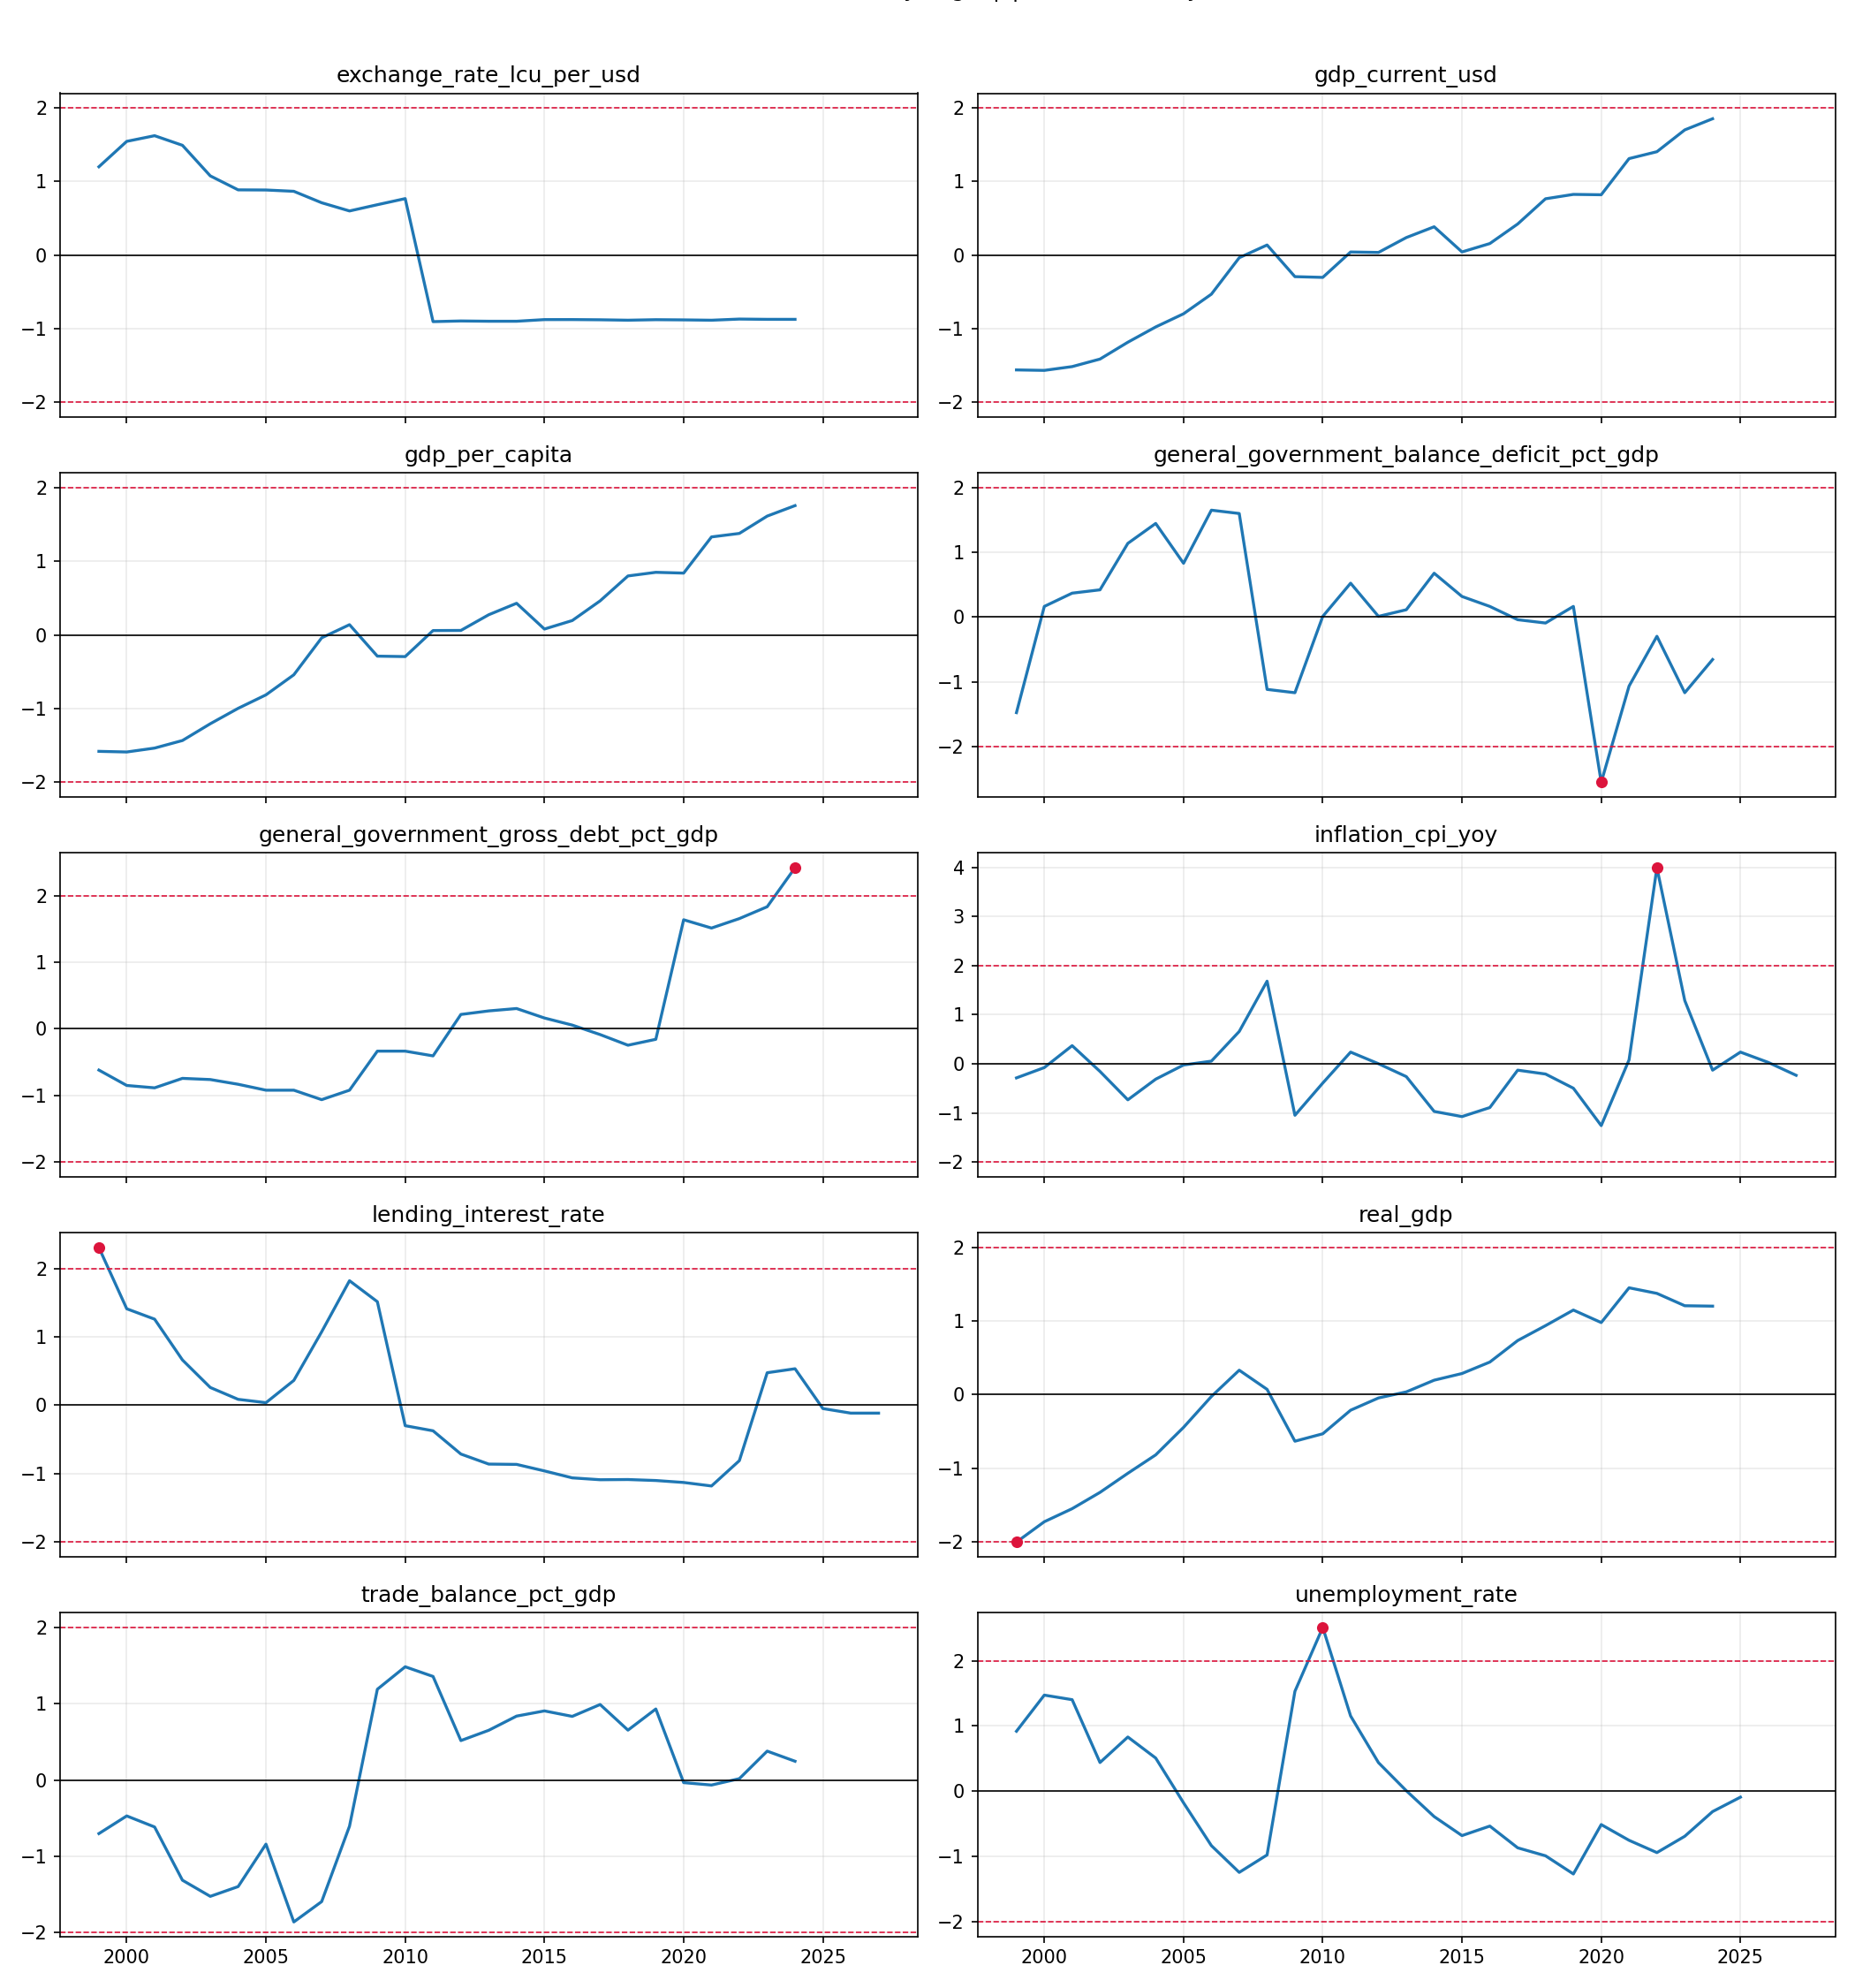

In [7]:
_ee_context = _render_country_normalized_section("EE")


## Inflation rolling override example

This example keeps the default static baseline for most indicators while switching inflation to a rolling trailing z-score window.


In [8]:
inflation_rolling_override_config = {
    "mode": "static_baseline",
    "baseline_start_year": 1999,
    "limit_to_baseline_window": True,
    "min_obs_for_zscore": 3,
    "indicator_overrides": {
        "inflation_cpi_yoy": {
            "mode": "rolling_trailing",
            "rolling_window_years": 10,
            "exclude_current_from_window": True,
            "min_obs_for_zscore": 5,
        }
    },
}


## Dynamic z-score visuals

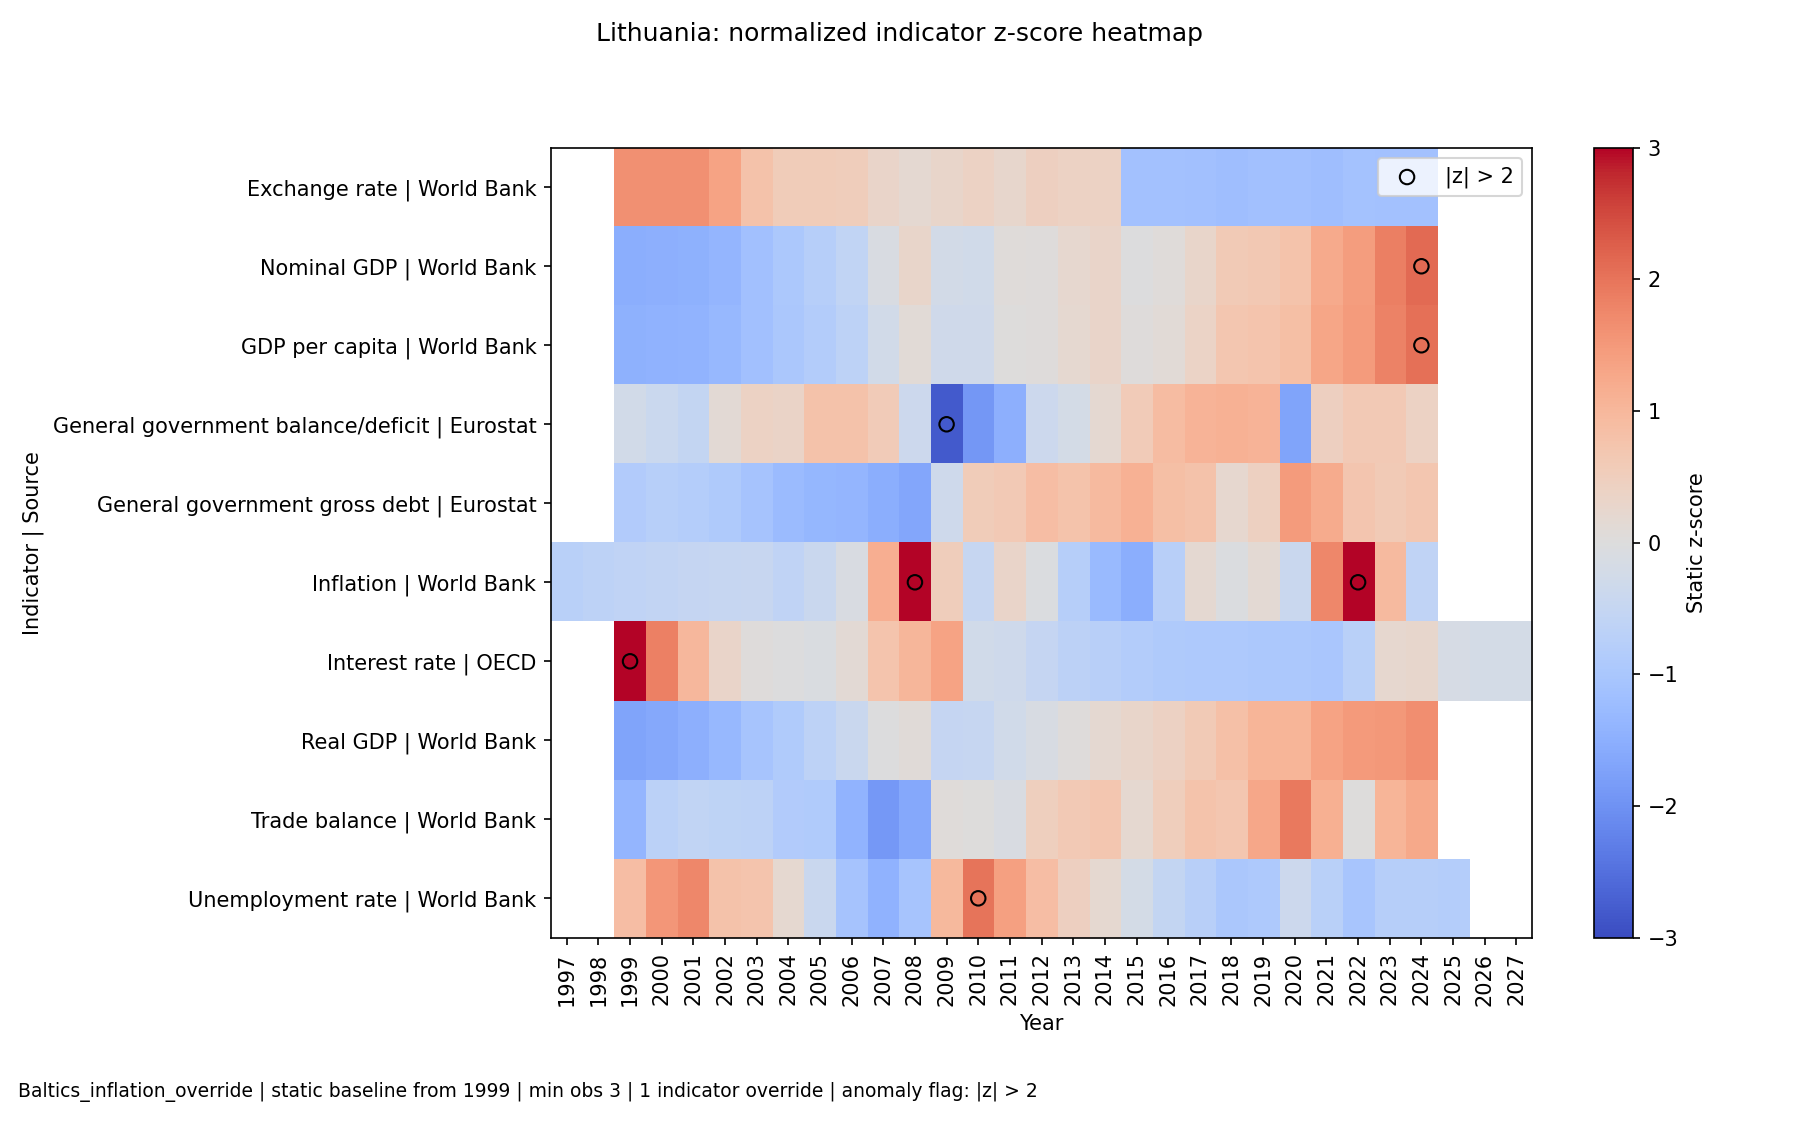

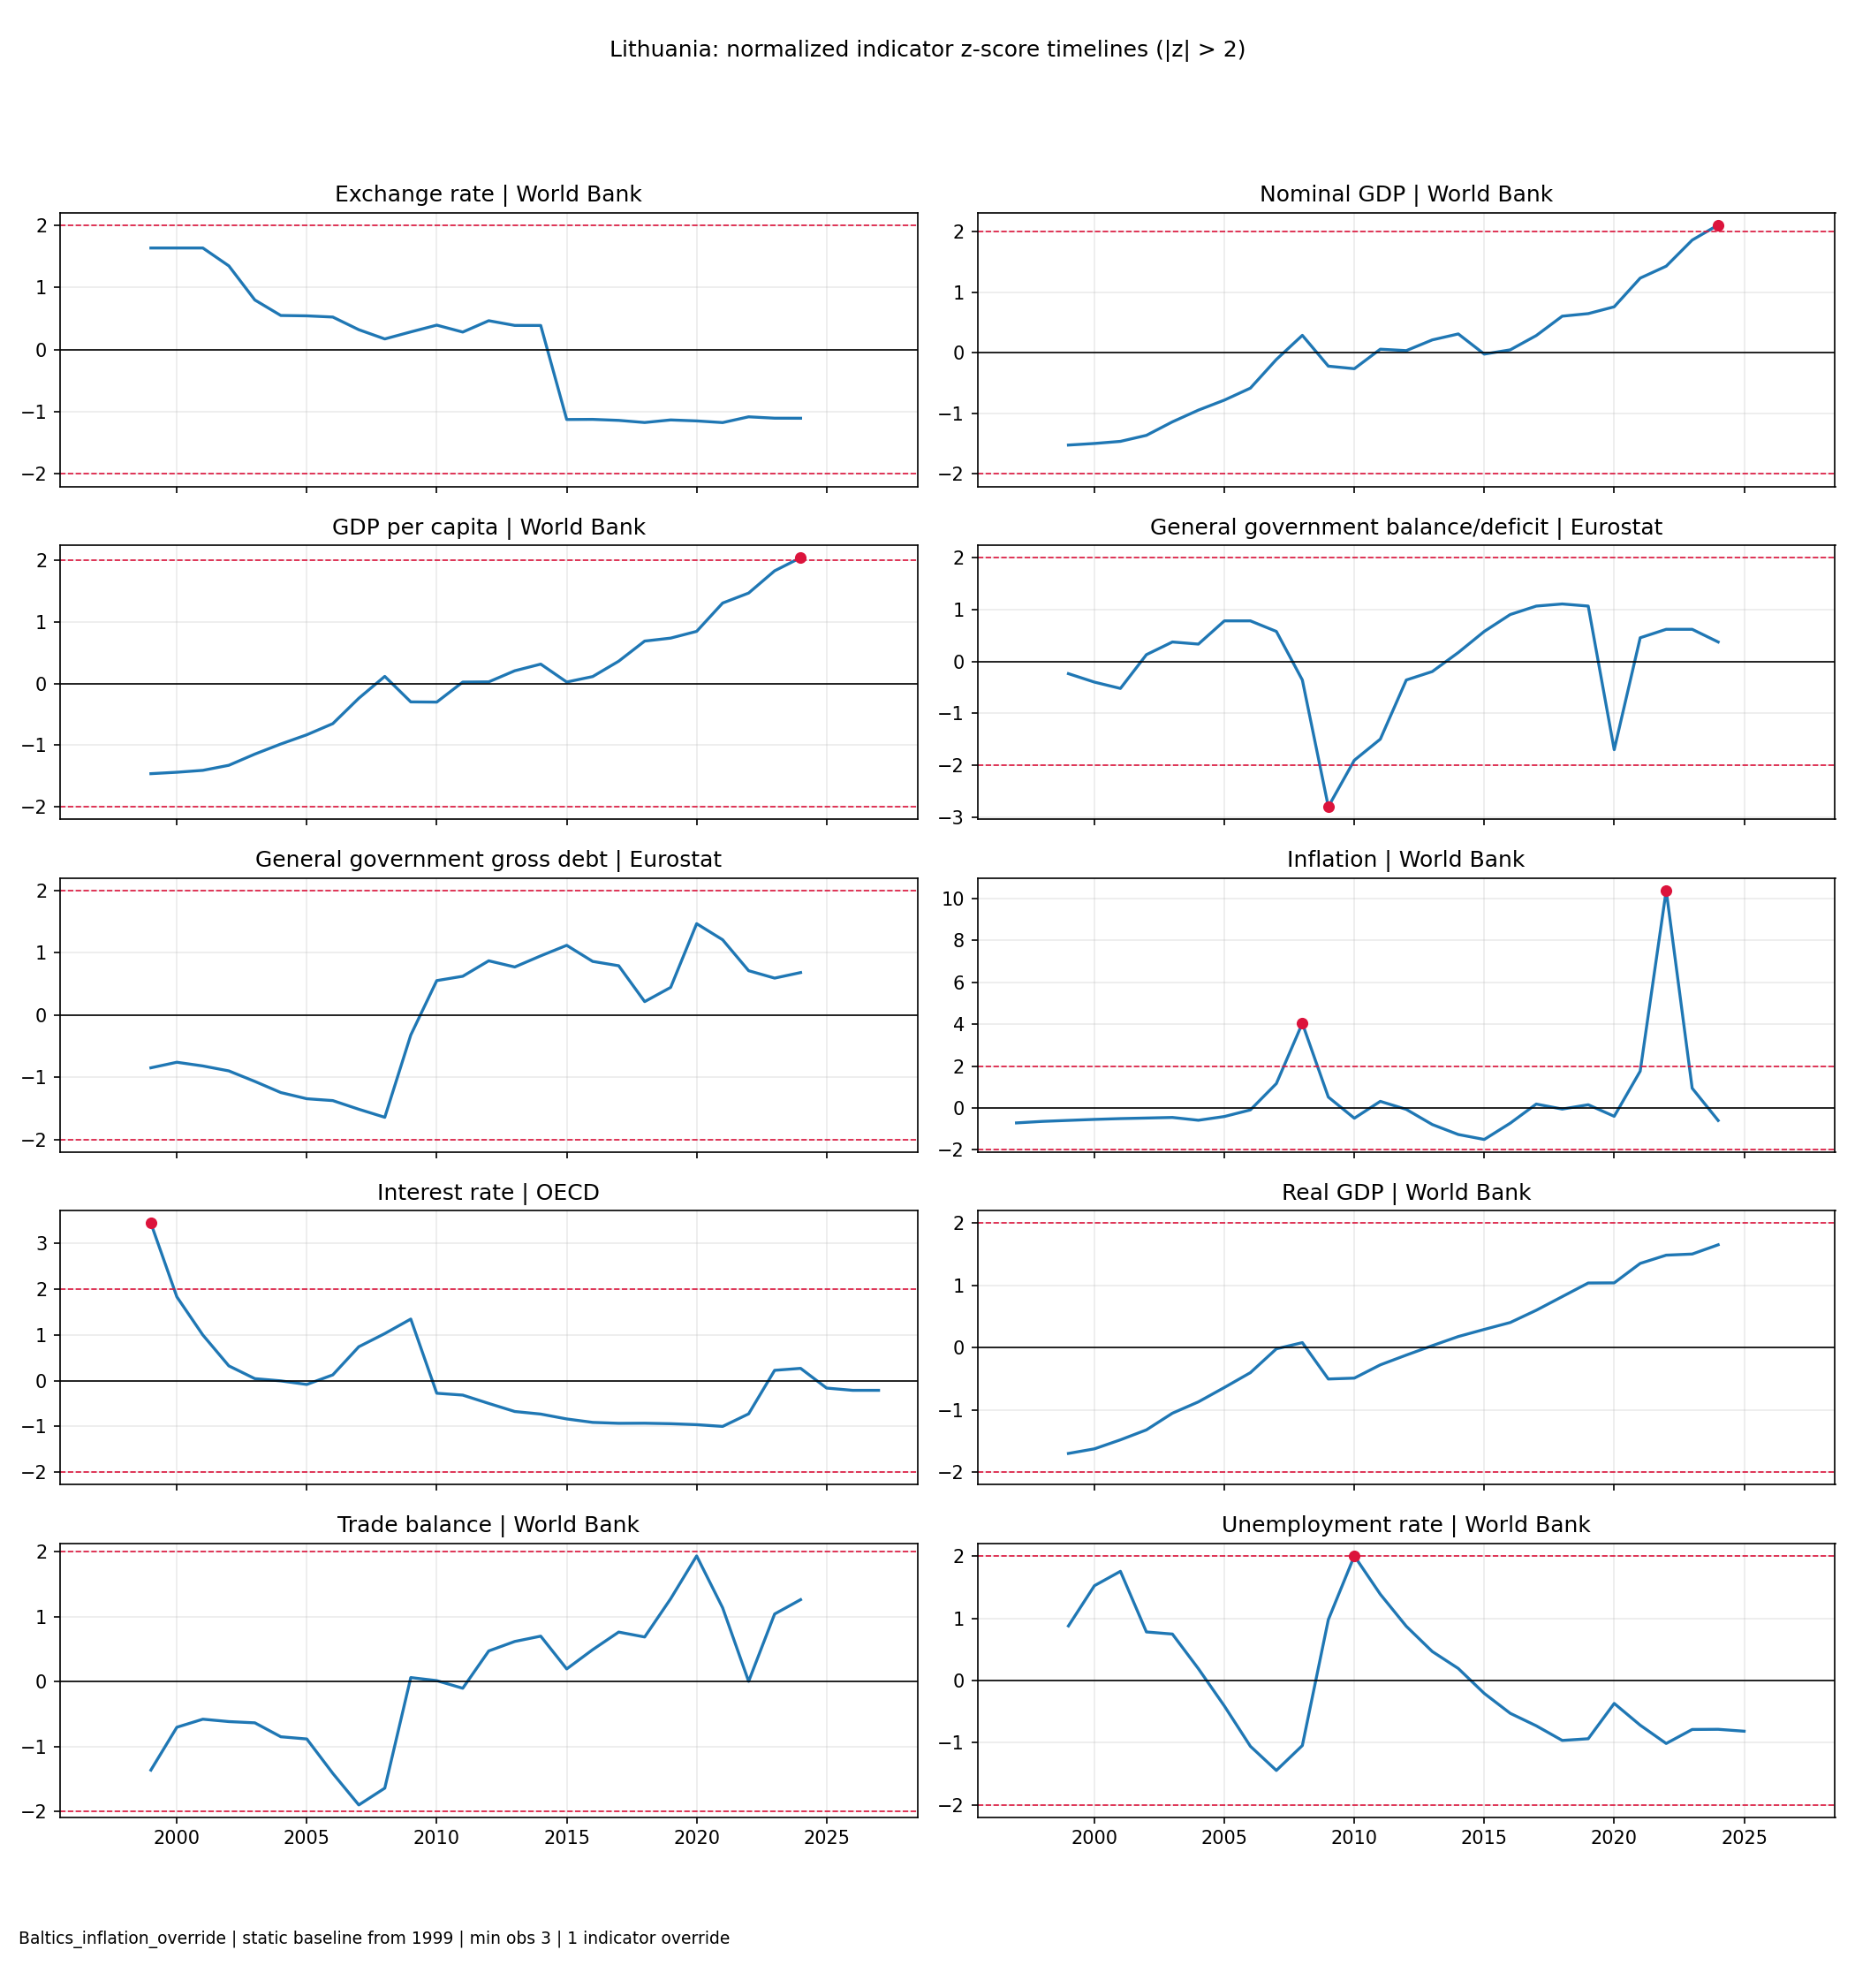

In [9]:
_lt_inflation_override_context = _render_country_normalized_section(
    "LT",
    normalization_config=inflation_rolling_override_config,
    region_label=f"{normalized_region_label}_inflation_override",
)


This notebook validates normalized-only per-country rendering from the shared Baltic batch artifacts.
